# Oráculo: mapas de clutter

Oráculo de `docs/algorithms/mapas-de-clutter.md`, independiente de cualquier
crate Rust (todavía no existe implementación — primer paso del método de
`docs/algorithms/roadmap.md` §"Método de estudio").

La página tiene dos mitades: **generación** (acumular barridos de cielo
despejado y decidir qué celdas son clutter) y **aplicación** (consultar el
mapa para decidir si filtrar). Este notebook cubre ambas con lo que exige el
criterio de aceptación: tasas de detección/falsa alarma en la generación —
incluido el caso de eco meteorológico persistente que no debe entrar al
mapa, y uno de propagación anómala intermitente— y ausencia de daño
colateral en la aplicación.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(20260909)
plt.rcParams["figure.figsize"] = (9, 4)
np.set_printoptions(precision=4, suppress=True)

## Por qué la generación necesita dos estadísticos, no uno

Un mapa basado sólo en potencia media confunde clutter con cualquier eco
persistente, incluida precipitación estancada. La página lo resuelve
pidiendo también variabilidad temporal: clutter de tierra es la **misma**
amplitud compleja barrido tras barrido (sólo cambia el ruido aditivo);
meteoro es una realización nueva e independiente cada barrido (la turbulencia
decorrelaciona el eco entre barridos separados por el tiempo de un volumen
completo). Por eso el generador de clutter de este oráculo dibuja la
amplitud **una vez** y la reutiliza en los `N_SWEEPS` barridos, mientras que
el generador de meteoro dibuja una señal nueva en cada barrido — es la
diferencia física real que el estadístico de variabilidad temporal está
midiendo, no un truco de la simulación.

In [2]:
def gaussian_doppler_spectrum(power_s, mean_v, sigma_v, wavelength_m, prt_s, m, wrap=3):
    v_a = wavelength_m / (4.0 * prt_s)
    f_k = np.fft.fftfreq(m, d=prt_s)
    v_k = f_k * wavelength_m / 2.0
    n = np.arange(-wrap, wrap + 1)
    dv = v_k[:, None] - mean_v - n[None, :] * 2.0 * v_a
    acc = np.exp(-0.5 * (dv / sigma_v) ** 2).sum(axis=1)
    return power_s * acc / acc.sum()


def complex_gaussian(rng, variance, size=None):
    sigma = np.sqrt(variance / 2.0)
    return rng.normal(0.0, sigma, size=size) + 1j * rng.normal(0.0, sigma, size=size)


def generate_weather_cell(power_s, mean_v, sigma_v, wavelength_m, prt_s, m, noise_floor, rng, wrap=3):
    """Una realización nueva e independiente por llamada — turbulencia real."""
    spectrum = gaussian_doppler_spectrum(power_s, mean_v, sigma_v, wavelength_m, prt_s, m, wrap)
    w = complex_gaussian(rng, 1.0, size=m)
    shaped = w * np.sqrt(spectrum)
    y = np.fft.ifft(shaped) * m
    if noise_floor > 0.0:
        y = y + complex_gaussian(rng, noise_floor, size=m)
    return y


def generate_static_clutter_cell(fixed_amplitude, m, noise_floor, rng):
    """Amplitud fija: blanco estacionario de verdad. Sólo el ruido aditivo
    cambia pulso a pulso y barrido a barrido."""
    y = np.full(m, fixed_amplitude, dtype=complex)
    if noise_floor > 0.0:
        y = y + complex_gaussian(rng, noise_floor, size=m)
    return y


def periodogram_raw(y):
    m = len(y)
    yf = np.fft.fft(y)
    return (np.abs(yf) ** 2) / (m ** 2)


def hildebrand_sekhon(p, navg=1):
    p_sorted = np.sort(p)
    n = len(p_sorted)
    rtest = 1.0 + 1.0 / navg
    nnoise = n
    sum1 = 0.0
    sum2 = 0.0
    for i in range(n):
        pwr = p_sorted[i]
        npts = i + 1
        sum1 += pwr
        sum2 += pwr * pwr
        if npts * sum2 < sum1 * sum1 * rtest:
            nnoise = npts
        else:
            sum1 -= pwr
            sum2 -= pwr * pwr
            break
    return sum1 / nnoise


def noise_floor_estimate(y):
    return hildebrand_sekhon(periodogram_raw(y)) * len(y)


def power_estimate(y):
    r0 = np.mean(np.abs(y) ** 2)
    n_hat = noise_floor_estimate(y)
    return max(r0 - n_hat, 0.0)


checks = []

## Generación: cuatro tipos de celda, treinta barridos cada una

- **clutter**: amplitud fija, presente en los 30 barridos.
- **weather**: meteoro con la *misma potencia media* que el clutter (el caso
  difícil — si el mapa se fijara sólo en potencia, no podría distinguirlos),
  realización nueva cada barrido.
- **clear**: sin señal, sólo ruido.
- **ap** (propagación anómala): la misma amplitud fija que "clutter", pero
  presente en sólo el 40% de los barridos al azar — clutter transitorio, que
  la página pide excluir explícitamente del mapa estático.

Regla de clasificación: `potencia_media > umbral_potencia` **y**
`CV temporal < umbral_cv`, con `CV = std/media` de la potencia estimada por
barrido. El umbral de CV es el que hace el trabajo real —separa clutter
(variación sólo por ruido de estimación) de todo lo demás (variación por
decorrelación física o por presencia intermitente).

clutter     marcada como clutter en 96.7% de 300 celdas


weather     marcada como clutter en 0.0% de 300 celdas


clear       marcada como clutter en 0.0% de 300 celdas


ap          marcada como clutter en 0.0% de 300 celdas


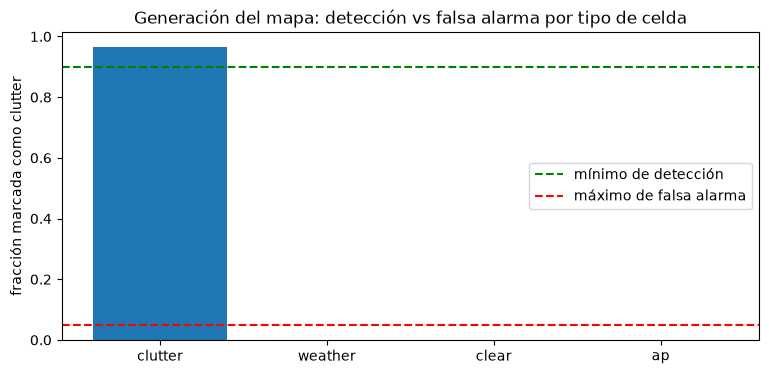

In [3]:
WAVELENGTH_M, PRT_S, M = 0.10, 1.0e-3, 64
NOISE_FLOOR = 0.05
N_SWEEPS = 30
POWER_CLUTTER = 5.0
POWER_WEATHER = 5.0  # misma potencia media que el clutter, a proposito
SIGMA_V_WEATHER = 2.0
AP_PRESENCE_FRAC = 0.4


def sweep_series(cell_type, rng):
    powers = []
    if cell_type == "clutter":
        amp = complex_gaussian(rng, POWER_CLUTTER)
        for _ in range(N_SWEEPS):
            powers.append(power_estimate(generate_static_clutter_cell(amp, M, NOISE_FLOOR, rng)))
    elif cell_type == "weather":
        for _ in range(N_SWEEPS):
            powers.append(power_estimate(
                generate_weather_cell(POWER_WEATHER, 0.0, SIGMA_V_WEATHER, WAVELENGTH_M, PRT_S, M, NOISE_FLOOR, rng)))
    elif cell_type == "clear":
        for _ in range(N_SWEEPS):
            powers.append(power_estimate(
                generate_weather_cell(0.0, 0.0, 1.0, WAVELENGTH_M, PRT_S, M, NOISE_FLOOR, rng)))
    elif cell_type == "ap":
        amp = complex_gaussian(rng, POWER_CLUTTER)
        present = rng.random(N_SWEEPS) < AP_PRESENCE_FRAC
        for pres in present:
            if pres:
                powers.append(power_estimate(generate_static_clutter_cell(amp, M, NOISE_FLOOR, rng)))
            else:
                powers.append(power_estimate(
                    generate_weather_cell(0.0, 0.0, 1.0, WAVELENGTH_M, PRT_S, M, NOISE_FLOOR, rng)))
    return np.array(powers)


CV_THRESHOLD = 0.15
POWER_THRESHOLD = 0.05


def is_clutter_cell(powers):
    mean_p = powers.mean()
    cv = powers.std() / mean_p if mean_p > 0 else np.inf
    return (mean_p > POWER_THRESHOLD) and (cv < CV_THRESHOLD)


N_CELLS = 300
DETECTION_MIN = 0.90
FALSE_ALARM_MAX = 0.05

rates = {}
for cell_type in ["clutter", "weather", "clear", "ap"]:
    flagged = sum(is_clutter_cell(sweep_series(cell_type, rng)) for _ in range(N_CELLS))
    rates[cell_type] = flagged / N_CELLS
    print(f"{cell_type:10s}  marcada como clutter en {rates[cell_type]:.1%} de {N_CELLS} celdas")

checks.append((f"tasa de detección de clutter verdadero >= {DETECTION_MIN:.0%}", rates["clutter"] >= DETECTION_MIN))
checks.append((f"falsa alarma sobre meteoro persistente (misma potencia que el clutter) <= {FALSE_ALARM_MAX:.0%}",
               rates["weather"] <= FALSE_ALARM_MAX))
checks.append((f"falsa alarma sobre cielo despejado <= {FALSE_ALARM_MAX:.0%}", rates["clear"] <= FALSE_ALARM_MAX))
checks.append((f"falsa alarma sobre propagación anómala intermitente <= {FALSE_ALARM_MAX:.0%}",
               rates["ap"] <= FALSE_ALARM_MAX))

fig, ax = plt.subplots()
ax.bar(rates.keys(), rates.values())
ax.axhline(DETECTION_MIN, color="green", linestyle="--", label="mínimo de detección")
ax.axhline(FALSE_ALARM_MAX, color="red", linestyle="--", label="máximo de falsa alarma")
ax.set_ylabel("fracción marcada como clutter"); ax.legend()
ax.set_title("Generación del mapa: detección vs falsa alarma por tipo de celda")
plt.show()

## Aplicación: sin daño colateral en celdas sin clutter

El mapa gobierna `clutter_width_ms` celda a celda: sin clutter esperado, el
ancho es 0 y el filtro no debe tocar nada. La forma correcta de implementar
eso es que "ancho 0" sea *el mismo camino de código* que "sin filtro", no una
rama aparte — así una celda sin clutter no puede sufrir un filtro mal
deshabilitado. Se comprueba reutilizando el filtro GMAP del oráculo de
`gmap-clutter-filtering.md` con `clutter_width_ms=0` y verificando que
coincide, a precisión de punto flotante, con no filtrar en absoluto.

In [4]:
def gmap_filter(P, v_k, clutter_mask, noise_thresh_per_bin, margin=3.0):
    P_filtered = P.copy()
    if not clutter_mask.any():
        return P_filtered  # mascara vacia: no hay nada que reemplazar, camino identico a "sin filtro"
    signal_mask = (~clutter_mask) & (P > margin * noise_thresh_per_bin)
    if signal_mask.sum() < 4:
        P_filtered[clutter_mask] = 0.0
        return P_filtered
    logp = np.log(np.maximum(P[signal_mask], 1e-300))
    design = np.vstack([np.ones(signal_mask.sum()), v_k[signal_mask], v_k[signal_mask] ** 2]).T
    coeffs, *_ = np.linalg.lstsq(design, logp, rcond=None)
    if coeffs[2] >= 0.0:
        P_filtered[clutter_mask] = 0.0
        return P_filtered
    v_clutter = v_k[clutter_mask]
    pred = coeffs[0] + coeffs[1] * v_clutter + coeffs[2] * v_clutter ** 2
    P_filtered[clutter_mask] = np.exp(pred)
    return P_filtered


F_K = np.fft.fftfreq(M, d=PRT_S)
V_K = F_K * WAVELENGTH_M / 2.0
EMPTY_CLUTTER_MASK = np.zeros(M, dtype=bool)  # mapa dice: sin clutter en esta celda -> ancho 0

max_abs_diff = 0.0
for _ in range(200):
    y = generate_weather_cell(POWER_WEATHER, 3.0, SIGMA_V_WEATHER, WAVELENGTH_M, PRT_S, M, NOISE_FLOOR, rng)
    n_hat = noise_floor_estimate(y) / M
    win = np.hanning(M)
    P = np.abs(np.fft.fft(y * win)) ** 2 / (M * np.sum(win ** 2))
    P_governed = gmap_filter(P, V_K, EMPTY_CLUTTER_MASK, n_hat)
    max_abs_diff = max(max_abs_diff, np.max(np.abs(P_governed - P)))

print(f"máxima diferencia entre 'gobernado por el mapa, ancho 0' y 'sin filtro': {max_abs_diff:.2e}")
checks.append(("celdas sin clutter (ancho 0) son bit-idénticas a no filtrar, sin rama de código aparte",
               max_abs_diff < 1e-12))

máxima diferencia entre 'gobernado por el mapa, ancho 0' y 'sin filtro': 0.00e+00


## Fuera de alcance, declarado

- **Dependencia con la elevación** y **ciclo de vida/versionado** del mapa
  son requisitos de procedimiento y de arquitectura de datos (mapa
  tridimensional, trazabilidad de qué versión procesó qué volumen), sin una
  fórmula ni una verdad-terreno numérica propia que un notebook pueda
  contrastar.
- **Detector dinámico tipo CMD**: la propia página lo marca como mejora de
  Stage 2 que necesita datos reales de ajuste — "un detector sin ajustar es
  peor que un mapa". No hay verdad-terreno sintética razonable para su
  criterio de decisión (combina textura espacial, posición espectral y ρHV)
  sin inventar un modelo que no está especificado en ningún lado.

In [5]:
all_ok = True
for name, ok in checks:
    print(f"[{'OK' if ok else 'FALLO'}] {name}")
    all_ok = all_ok and ok

assert all_ok, "el oráculo de mapas de clutter no pasa todas las comprobaciones — ver tabla arriba"
print("\nTodas las comprobaciones dentro de tolerancia.")

[OK] tasa de detección de clutter verdadero >= 90%
[OK] falsa alarma sobre meteoro persistente (misma potencia que el clutter) <= 5%
[OK] falsa alarma sobre cielo despejado <= 5%
[OK] falsa alarma sobre propagación anómala intermitente <= 5%
[OK] celdas sin clutter (ancho 0) son bit-idénticas a no filtrar, sin rama de código aparte

Todas las comprobaciones dentro de tolerancia.
